# EE 344 — Assignment 5: Power-System Fault Classification with Deep Neural Networks

In this assignment, you will predict **power-system fault conditions** from 6 input measurements using **PyTorch**.
There are many ways to implement DNNs for prediction tasks; here you will implement and compare **three** common setups.

**Dataset**: `classData.csv`

**Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`  
**Outputs**: 4-bit label `[G, C, B, A]`

Dataset (Kaggle): https://www.kaggle.com/datasets/esathyaprakash/electrical-fault-detection-and-classification

**Note:** Do **NOT** download the dataset from Kaggle. Use the dataset file provided on Canvas with this assignment.

Your tasks:
1. **Part 1** — Regression-style DNN to predict 4 outputs (then round to bits).
2. **Part 2** — Multi-label DNN to predict 4 bits (sigmoid / BCE-style loss).
3. **Part 3** — Multi-class DNN to predict no fault and 5 fault types (softmax / cross-entropy).
4. **Part 4** — Brief discussion: which approach is best and why.
5. **Part 5** — Open-ended: build a **binary** classifier (Fault vs No Fault) using the best approach.


## Setup
Run the next cell to import libraries and define helper functions.

In [30]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def plot_cm(cm, title, labels):
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45, ha='right')
    plt.yticks(ticks, labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

def bit_reports(Y_true_bits, Y_pred_bits, split_name='Test', bit_names=('G','C','B','A')):
    """Multi-label report + per-bit 2x2 confusion matrices."""
    print(f"\n=== Bit-level Report | {split_name} ===")
    print(classification_report(Y_true_bits, Y_pred_bits, target_names=list(bit_names), digits=4))
    for j, lab in enumerate(bit_names):
        cm = confusion_matrix(Y_true_bits[:, j], Y_pred_bits[:, j], labels=[0, 1])
        print(f"\nBit {lab} | {split_name} CM (rows=true 0/1, cols=pred 0/1):\n{cm}")


Device: cpu


## Dataset

The file `classData.csv` contains a dataset for classifying fault conditions.

- **Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`
- **Outputs**: `[G, C, B, A]`

Examples:
- `[0 0 0 0]` — No Fault
- `[1 0 0 1]` — LG fault (Phase A to ground)
- `[0 0 1 1]` — LL fault (Phase A to Phase B)
- `[1 0 1 1]` — LLG fault (Phases A,B to ground)
- `[0 1 1 1]` — LLL fault (all three phases)
- `[1 1 1 1]` — LLLG fault (three phases + ground)


In [31]:
# ----------------------------
# Load data + create targets
# ----------------------------
CSV_PATH = 'data/classData.csv'
df = pd.read_csv(CSV_PATH)

label_cols = ['G','C','B','A']
feature_cols = ['Ia','Ib','Ic','Va','Vb','Vc']

missing = [c for c in (label_cols + feature_cols) if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}. Found: {list(df.columns)}")

X = df[feature_cols].astype(np.float32).values            # (N,6)
Y_bits = df[label_cols].astype(int).values                # (N,4)

FAULT_NAMES = ['No Fault','LG','LL','LLG','LLL','LLLG']

def bits_to_fault_type_idx(bits_gcba):
    G, C, B, A = map(int, bits_gcba)
    n_phase = C + B + A
    if G == 0 and n_phase == 0: return 0
    if G == 1 and n_phase == 1: return 1
    if G == 0 and n_phase == 2: return 2
    if G == 1 and n_phase == 2: return 3
    if G == 0 and n_phase == 3: return 4
    if G == 1 and n_phase == 3: return 5
    raise ValueError(f"Unexpected pattern [G,C,B,A]={bits_gcba}")

y_fault = np.array([bits_to_fault_type_idx(row) for row in Y_bits], dtype=int)
print('Fault counts:', dict(zip(FAULT_NAMES, np.bincount(y_fault, minlength=len(FAULT_NAMES)))))

# One shared split (recommended for fair comparison across Parts 1–3)
X_train, X_test, Y_train, Y_test, y_fault_train, y_fault_test = train_test_split(
    X, Y_bits, y_fault, test_size=0.30, random_state=RANDOM_STATE, stratify=y_fault
)
print('Train size:', X_train.shape, '| Test size:', X_test.shape)


Fault counts: {'No Fault': np.int64(2365), 'LG': np.int64(1129), 'LL': np.int64(1004), 'LLG': np.int64(1134), 'LLL': np.int64(1096), 'LLLG': np.int64(1133)}
Train size: (5502, 6) | Test size: (2359, 6)


## Part 1 — DNN Model 1 (Regression-style 4-output model)

You will build a DNN that outputs **4 real-valued numbers** and train it with **MSE**.
During evaluation, you will **round** predictions to the nearest integer, clamp to `{0,1}`, and then compare against the true 4-bit label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 (linear)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**


In [32]:
# ----------------------------
# Part 1: Robust scaling (fit on train only)
# ----------------------------
scaler_1 = RobustScaler()
X_train_s1 = scaler_1.fit_transform(X_train).astype(np.float32)
X_test_s1  = scaler_1.transform(X_test).astype(np.float32)

# Torch datasets
Xtr = torch.from_numpy(X_train_s1)
Xte = torch.from_numpy(X_test_s1)
Ytr = torch.from_numpy(Y_train.astype(np.float32))
Yte = torch.from_numpy(Y_test.astype(np.float32))

BATCH_SIZE = 256
train_loader_1 = DataLoader(TensorDataset(Xtr, Ytr), batch_size=BATCH_SIZE, shuffle=True)

# Hyperparameters
INPUT_DIM = 6
H1 = 16
H2 = 8
OUT_DIM = 4
DROPOUT_P = 0.25
L2_WEIGHT_DECAY = 1e-4
LR = 1e-3
EPOCHS = 100


In [33]:
## [ TODO 1 ]
# Define the DNN for Part 1 using PyTorch.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 4
# - Hidden activations: ReLU
# - Output: linear (no activation)
# - Use BatchNorm and Dropout in hidden layers
#
# Write your model class below.

class DNN_Reg4(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, out_dim=OUT_DIM, p_drop=DROPOUT_P):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.drop1 = nn.Dropout(p_drop)
        
        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.drop2 = nn.Dropout(p_drop)
        
        self.fc3 = nn.Linear(h2, out_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.drop1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.drop2(x)
        
        x = self.fc3(x)
        return x


In [34]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: MSE
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

model = DNN_Reg4().to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=L2_WEIGHT_DECAY)

In [35]:
# ----------------------------
# Training loop (you fill the key missing pieces)
# ----------------------------
def train_part1(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            optimizer.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            # Print average loss
            avg_loss = total / len(loader.dataset)
            print(f'Epoch {ep}/{epochs} | Loss: {avg_loss:.6f}')

@torch.no_grad()
def predict_part1(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    out = model(X_t).cpu().numpy()  # (N,4) real-valued
    return out

# Train the model
train_part1(model, train_loader_1)


Epoch 1/100 | Loss: 0.766126
Epoch 50/100 | Loss: 0.124755
Epoch 100/100 | Loss: 0.112544


In [36]:
# ----------------------------
# Evaluation (round -> clamp to {0,1} -> report)
# ----------------------------
yhat_train = predict_part1(model, X_train_s1)
yhat_test  = predict_part1(model, X_test_s1)

# After you obtain yhat_* (shape N x 4):
pred_bits_train = np.clip(np.rint(yhat_train).astype(int), 0, 1)
pred_bits_test  = np.clip(np.rint(yhat_test ).astype(int), 0, 1)
bit_reports(Y_train, pred_bits_train, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.9231    0.7270    0.8134      2377
           C     0.9951    0.8988    0.9445      2263
           B     0.9993    0.8904    0.9417      3057
           A     0.9598    0.9637    0.9618      3144

   micro avg     0.9711    0.8776    0.9220     10841
   macro avg     0.9693    0.8700    0.9153     10841
weighted avg     0.9702    0.8776    0.9200     10841
 samples avg     0.6497    0.6183    0.6287     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[2981  144]
 [ 649 1728]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[3229   10]
 [ 229 2034]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[2443    2]
 [ 335 2722]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[2231  127]
 [ 114 3030]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.9231    0.7301    0.8153      1019
           C     0.9977    

C:\Users\henry\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\henry\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\henry\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

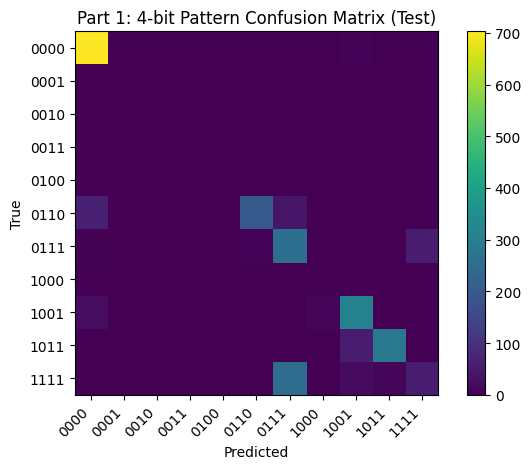

[[703   1   0   0   0   0   0   0   6   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0]
 [ 63   0   0   0   1 198  39   0   0   0   0]
 [  5   0   2   1   0   7 258   0   0   0  56]
 [  0   0   0   0   0   0   0   0   0   0   0]
 [ 22   0   0   0   0   0   0   9 308   0   0]
 [  1   0   0   0   0   0   0   0  56 281   2]
 [  1   0   0   0   0   0 251   0  20  11  57]]


In [37]:
# One confusion matrix over full 4-bit patterns (for TEST set)
true_str = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str = [''.join(map(str, r.tolist())) for r in pred_bits_test]
labels = sorted(list(set(true_str) | set(pred_str)))
cm = confusion_matrix(true_str, pred_str, labels=labels)
plot_cm(cm, 'Part 1: 4-bit Pattern Confusion Matrix (Test)', labels)
print(cm)

## Part 2 — DNN Model 2 (Multi-label 4-bit classification)

You will build a DNN that predicts the 4 bits `[G, C, B, A]` as a **multi-label** output.
Each output dimension is an independent binary label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 logits (apply sigmoid only for evaluation)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use a **binary cross-entropy style loss on logits** (do not apply sigmoid inside the model).


In [38]:
# ----------------------------
# Part 2: Robust scaling (fit on train only)
# ----------------------------
scaler_2 = RobustScaler()
X_train_s2 = scaler_2.fit_transform(X_train).astype(np.float32)
X_test_s2  = scaler_2.transform(X_test).astype(np.float32)

Xtr2 = torch.from_numpy(X_train_s2)
Xte2 = torch.from_numpy(X_test_s2)
Ytr2 = torch.from_numpy(Y_train.astype(np.float32))
Yte2 = torch.from_numpy(Y_test.astype(np.float32))

train_loader_2 = DataLoader(TensorDataset(Xtr2, Ytr2), batch_size=BATCH_SIZE, shuffle=True)


In [39]:
## [ TODO 1 ]
# Define the DNN for Part 2.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 4
# - Hidden activations: ReLU
# - Output: 4 logits (no sigmoid inside the model)
# - Use BatchNorm and Dropout in hidden layers

class DNN_MultiLabel4(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, out_dim=OUT_DIM, p_drop=DROPOUT_P):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.drop1 = nn.Dropout(p_drop)
        
        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.drop2 = nn.Dropout(p_drop)
        
        self.fc3 = nn.Linear(h2, out_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.drop1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.drop2(x)
        
        x = self.fc3(x)
        return x


In [40]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: binary cross-entropy style loss on logits -- BCEWithLogitsLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

model = DNN_MultiLabel4().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=L2_WEIGHT_DECAY)

In [41]:
# ----------------------------
# Training loop scaffold
# ----------------------------
## [ TODO 3]
def train_part2(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            # print epoch + average loss
            print(f"Epoch {ep}, Average Loss: {total / len(loader.dataset)}")

@torch.no_grad()
def predict_bits_part2(model, X_np, threshold=0.5):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    probs = torch.sigmoid(logits).cpu().numpy()
    pred_bits = (probs >= threshold).astype(int)
    return pred_bits

train_part2(model, train_loader_2, epochs=EPOCHS)

Epoch 1, Average Loss: 0.734712481888716
Epoch 50, Average Loss: 0.2782899366210305
Epoch 100, Average Loss: 0.24010948723595776


In [42]:
# ----------------------------
# Evaluation
# ----------------------------
pred_bits_train_ = predict_bits_part2(model, X_train_s2)
pred_bits_test_  = predict_bits_part2(model, X_test_s2)

bit_reports(Y_train, pred_bits_train_, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test_,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.8041    0.8788    0.8398      2377
           C     0.9551    0.9395    0.9472      2263
           B     0.9567    0.9676    0.9621      3057
           A     0.9846    0.9790    0.9818      3144

   micro avg     0.9284    0.9456    0.9369     10841
   macro avg     0.9251    0.9412    0.9327     10841
weighted avg     0.9310    0.9456    0.9379     10841
 samples avg     0.6419    0.6620    0.6471     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[2616  509]
 [ 288 2089]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[3139  100]
 [ 137 2126]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[2311  134]
 [  99 2958]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[2310   48]
 [  66 3078]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.8113    0.8734    0.8412      1019
           C     0.9561    

C:\Users\henry\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\henry\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\henry\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

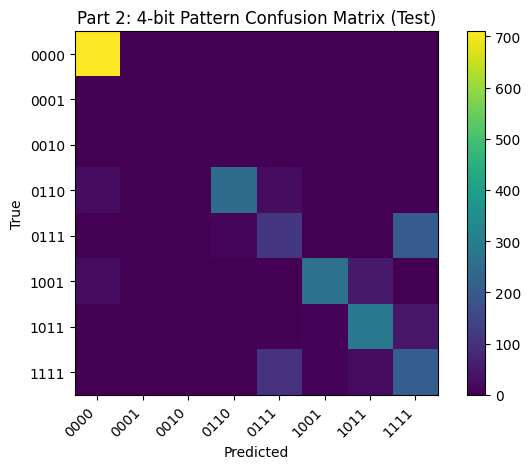

[[710   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [ 23   0   4 251  23   0   0   0]
 [  0   0   0  11 111   0   0 207]
 [ 20   5   0   0   0 262  52   0]
 [  1   1   0   0   0   8 288  42]
 [  0   1   0   1 100   7  20 211]]


In [43]:
# One confusion matrix over full 4-bit patterns (For TEST set)
true_str_ = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str_ = [''.join(map(str, r.tolist())) for r in pred_bits_test_]
labels_ = sorted(list(set(true_str_) | set(pred_str_)))
cm_ = confusion_matrix(true_str_, pred_str_, labels=labels_)
plot_cm(cm_, 'Part 2: 4-bit Pattern Confusion Matrix (Test)', labels_)
print(cm_)

## Part 3 — DNN Model 3 (Multi-class fault type classification)

In this part, you will predict one of **6 fault types**.
The 4-bit label is converted to a single class in `{0,1,2,3,4,5}` using the provided mapping.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 6 logits
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use **cross-entropy loss** for multi-class classification.


In [44]:
# ----------------------------
# Part 3: Robust scaling (fit on train only)
# ----------------------------
scaler_3 = RobustScaler()
X_train_s3 = scaler_3.fit_transform(X_train).astype(np.float32)
X_test_s3  = scaler_3.transform(X_test).astype(np.float32)

ytr3 = torch.from_numpy(y_fault_train.astype(np.int64))
yte3 = torch.from_numpy(y_fault_test.astype(np.int64))
Xtr3 = torch.from_numpy(X_train_s3)
Xte3 = torch.from_numpy(X_test_s3)

train_loader_3 = DataLoader(TensorDataset(Xtr3, ytr3), batch_size=BATCH_SIZE, shuffle=True)


In [45]:
## [ TODO 1 ]
# Define the DNN for Part 3.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 6
# - Hidden activations: ReLU
# - Output: 6 logits
# - Use BatchNorm and Dropout in hidden layers

class DNN_MultiClass6(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, num_classes=6, p_drop=DROPOUT_P):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.drop1 = nn.Dropout(p_drop)
        
        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.drop2 = nn.Dropout(p_drop)
        
        self.fc3 = nn.Linear(h2, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.drop1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.drop2(x)
        
        x = self.fc3(x)
        return x


In [46]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: CrossEntropyLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

model = DNN_MultiClass6().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=L2_WEIGHT_DECAY)

In [47]:
# ----------------------------
# Training loop scaffold
# ----------------------------
## [ TODO 3 ]
def train_part3(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            print(f"Epoch {ep}, Average Loss: {total / len(loader.dataset)}")

@torch.no_grad()
def predict_part3(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    return torch.argmax(logits, dim=1).cpu().numpy()

train_part3(model, train_loader_3, epochs=EPOCHS)


Epoch 1, Average Loss: 1.9454792735794162
Epoch 50, Average Loss: 0.7940328179684955
Epoch 100, Average Loss: 0.71611380980085



=== Part 3 | Train ===
              precision    recall  f1-score   support

    No Fault     0.9272    1.0000    0.9622      1655
          LG     0.8466    0.9291    0.8859       790
          LL     0.8368    0.9118    0.8727       703
         LLG     0.8738    0.8804    0.8770       794
         LLL     0.5090    0.8070    0.6243       767
        LLLG     0.5441    0.0467    0.0859       793

    accuracy                         0.7970      5502
   macro avg     0.7562    0.7625    0.7180      5502
weighted avg     0.7829    0.7970    0.7541      5502



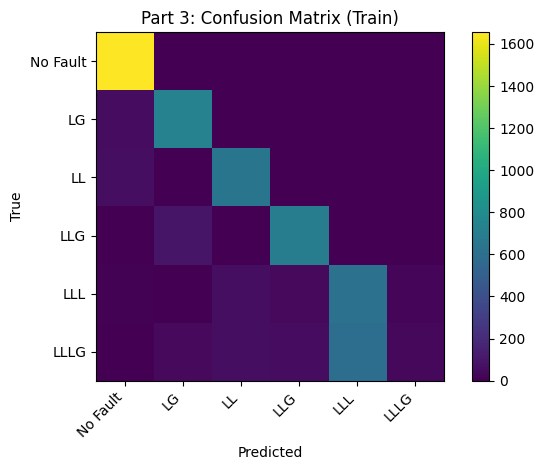


=== Part 3 | Test ===
              precision    recall  f1-score   support

    No Fault     0.9245    1.0000    0.9608       710
          LG     0.8414    0.9233    0.8805       339
          LL     0.8328    0.9103    0.8698       301
         LLG     0.8997    0.8706    0.8849       340
         LLL     0.5122    0.8298    0.6334       329
        LLLG     0.3929    0.0324    0.0598       340

    accuracy                         0.7957      2359
   macro avg     0.7339    0.7611    0.7149      2359
weighted avg     0.7632    0.7957    0.7512      2359



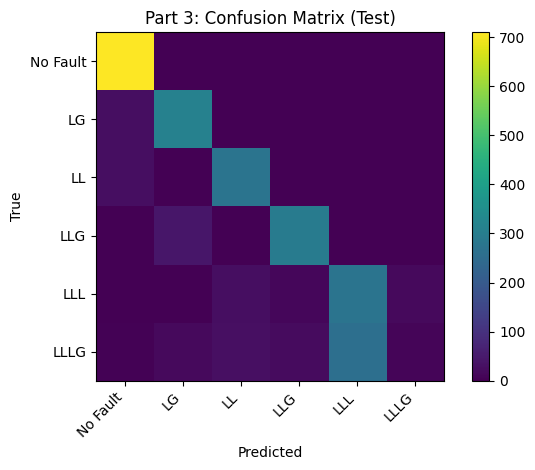

In [48]:
# ----------------------------
# Evaluation
# ----------------------------
pred_train = predict_part3(model, X_train_s3)
pred_test  = predict_part3(model, X_test_s3)

print('\n=== Part 3 | Train ===')
print(classification_report(y_fault_train, pred_train, target_names=FAULT_NAMES, digits=4))
cm_tr = confusion_matrix(y_fault_train, pred_train, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_tr, 'Part 3: Confusion Matrix (Train)', FAULT_NAMES)

print('\n=== Part 3 | Test ===')
print(classification_report(y_fault_test, pred_test, target_names=FAULT_NAMES, digits=4))
cm_te = confusion_matrix(y_fault_test, pred_test, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_te, 'Part 3: Confusion Matrix (Test)', FAULT_NAMES)


## Part 4 — Discussion

Answer **2–5 sentences** for each prompt.

1. Compare Parts 1–3. Which formulation fits this dataset best (regression-style, multi-label, or multi-class), and why?
2. When you used the bit-based approaches (Part 1 and Part 2), did you observe any **inconsistent 4-bit outputs** (invalid fault patterns)? What does that suggest?
3. Looking at confusion matrices, which fault types (or bit positions) were the hardest to predict? Give one plausible reason.

### Your answers
- Q1:The multi-label formulation fits the dataset best - we know this because the accuracy and (weighted average) f1 scores are highest for the multi-label model. The multi-label model has a weighted average F1 score of 0.9379, whereas the other models have weighted average F1 scores of 0.79 and 0.92 for the multi-class and regression models, respectively. Moreover, we should expect that the multi-class model underperforms - after all, the label contains extra information (namely, where the fault occurred) that gets erased when converting over to simple class numbering/one-hot encoding.
- Q2: Yes, for both models, we saw a small number of guesses of `0110`, which is not a valid bit pattern. This is of course theoretically possible given the nature of our output encoding (any output combination of 1s and 0s is possible). This could suggest that the model could benefit from more training epochs, or a larger dataset, since ideally, our model would learn to never guess an invalid fault pattern. alternatively, we could come up with a custom loss function that penalizes illegal guesses, but this seems quite involved and unnecessary.
- Q3: From the confusion matrices, the `1111` labelled data, i.e. a fault with all three phases plus ground, is the hardest to predict. It would be difficult to give a confident answer for 'why' this is the case without knowing more about the physical system that the data corresponds to. that said, it might be hardest to predict the `1111` fault because when *everything* fails, your system produces undefined and/or unpredictable behavior. In other words, it might be the case that the data points in the `1111` category have a lot of variance between each other, and thus it's hard for a machine learning model to learn a representation for that class.


## Part 5 — Open-ended extension: Binary classification (Fault vs No Fault)

In this part, you will create a **binary** classification problem:

- Class 0: **No Fault** (`[0,0,0,0]`)
- Class 1: **Fault** (any other pattern)

**Your task**: Using the best formulation you identified in Part 4, build a DNN to classify **Fault vs No Fault**.

Requirements:
- Use a **70% / 30%** train/test split (stratified)
- Use **RobustScaler** (fit on train only)
- Report **classification report** and **confusion matrix** on **train and test**

Implementation notes:
- First create a dataset with two classes by compressing all fault types into a single “Fault” class (and keeping “No Fault” as the other class).
- Keep your solution clean and focused: data, model, training, evaluation.


Note: because we are combining fault classes together, we will need to create new labels anyway. We choose to create 0 and 1 labels, and then have a single output neuron with binary cross entropy loss

Binary label counts (0=No Fault, 1=Fault): {np.int64(0): np.int64(2365), np.int64(1): np.int64(5496)}
Train size: (5502, 6) | Test size: (2359, 6)
Epoch 1/100 | Loss: 0.804763
Epoch 50/100 | Loss: 0.143660
Epoch 100/100 | Loss: 0.108084

=== Part 5 | Train ===
              precision    recall  f1-score   support

    No Fault     0.9184    1.0000    0.9575      1655
       Fault     1.0000    0.9618    0.9805      3847

    accuracy                         0.9733      5502
   macro avg     0.9592    0.9809    0.9690      5502
weighted avg     0.9755    0.9733    0.9736      5502



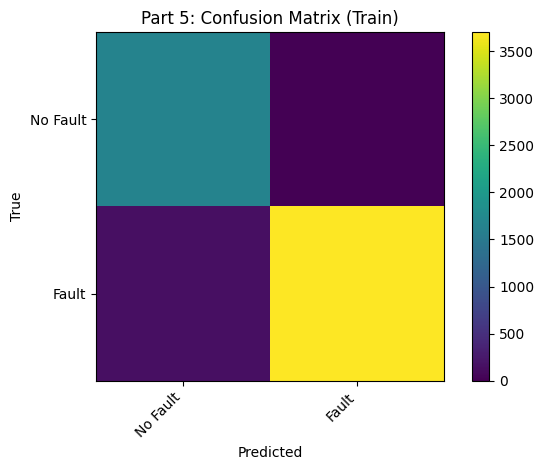

[[1655    0]
 [ 147 3700]]

=== Part 5 | Test ===
              precision    recall  f1-score   support

    No Fault     0.9293    1.0000    0.9634       710
       Fault     1.0000    0.9673    0.9834      1649

    accuracy                         0.9771      2359
   macro avg     0.9647    0.9836    0.9734      2359
weighted avg     0.9787    0.9771    0.9773      2359



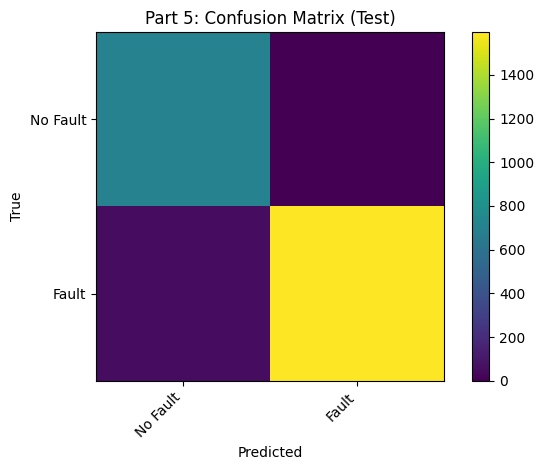

[[ 710    0]
 [  54 1595]]


In [49]:
# Build new binary labels from the original 4-bit label
y_binary = (Y_bits.sum(axis=1) > 0).astype(np.int64)

print('Binary label counts (0=No Fault, 1=Fault):', dict(zip(*np.unique(y_binary, return_counts=True))))

# 70/30 stratified split
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X, y_binary,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_binary
)
print('Train size:', Xb_train.shape, '| Test size:', Xb_test.shape)

# Robust scaling
scaler_b = RobustScaler()
Xb_train_s = scaler_b.fit_transform(Xb_train).astype(np.float32)
Xb_test_s  = scaler_b.transform(Xb_test).astype(np.float32)

# Torch datasets / loaders
Xtr_b = torch.from_numpy(Xb_train_s)
Xte_b = torch.from_numpy(Xb_test_s)
ytr_b = torch.from_numpy(yb_train.astype(np.float32)).unsqueeze(1)  # shape (N,1)
yte_b = torch.from_numpy(yb_test.astype(np.float32)).unsqueeze(1)    # shape (N,1)

train_loader_b = DataLoader(TensorDataset(Xtr_b, ytr_b), batch_size=BATCH_SIZE, shuffle=True)

# Model: 6 -> 16 -> 8 -> 1 (logit output)
class DNN_Binary(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, p_drop=DROPOUT_P):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.drop1 = nn.Dropout(p_drop)

        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.drop2 = nn.Dropout(p_drop)

        self.fc3 = nn.Linear(h2, 1)

    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.drop1(x)
        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.drop2(x)
        x = self.fc3(x)
        return x

model_b = DNN_Binary().to(device)
loss_fn_b = nn.BCEWithLogitsLoss()
optimizer_b = torch.optim.Adam(model_b.parameters(), lr=LR, weight_decay=L2_WEIGHT_DECAY)

def train_part5(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer_b.zero_grad()
            logits = model(xb)
            loss = loss_fn_b(logits, yb)
            loss.backward()
            optimizer_b.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs // 2, epochs]:
            print(f'Epoch {ep}/{epochs} | Loss: {total / len(loader.dataset):.6f}')

@torch.no_grad()
def predict_binary(model, X_np, threshold=0.5):
    model.eval()
    Xt = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(Xt)
    probs = torch.sigmoid(logits).cpu().numpy().ravel()
    preds = (probs >= threshold).astype(int)
    return preds, probs

train_part5(model_b, train_loader_b, epochs=EPOCHS)

# Evaluation (train + test): classification report + confusion matrix
pred_train_b, prob_train_b = predict_binary(model_b, Xb_train_s)
pred_test_b, prob_test_b   = predict_binary(model_b, Xb_test_s)

BIN_NAMES = ['No Fault', 'Fault']

print('\n=== Part 5 | Train ===')
print(classification_report(yb_train, pred_train_b, target_names=BIN_NAMES, digits=4))
cm_train_b = confusion_matrix(yb_train, pred_train_b, labels=[0, 1])
plot_cm(cm_train_b, 'Part 5: Confusion Matrix (Train)', BIN_NAMES)
print(cm_train_b)

print('\n=== Part 5 | Test ===')
print(classification_report(yb_test, pred_test_b, target_names=BIN_NAMES, digits=4))
cm_test_b = confusion_matrix(yb_test, pred_test_b, labels=[0, 1])
plot_cm(cm_test_b, 'Part 5: Confusion Matrix (Test)', BIN_NAMES)
print(cm_test_b)